In [2]:
import pandas as pd


In [3]:
df = pd.read_csv('Motor_Vehicle_Crashes.csv')
df.head()

,Year,Case Individual ID,Case Vehicle ID,Victim Status,Role Type,Seating Position,Ejection,License State Code,Sex,Transported By,Safety Equipment,Injury Descriptor,Injury Location,Injury Severity,Age
0,2021,23823595,18126389,Apparent Death,Driver of a Motor Vehicle in Transport,Driver,Unknown,NY,F,Unknown,Air Bag Deployed/Lap Belt/Harness,Internal,Entire Body,Killed,60.0
1,2021,25373125,18127394,Not Entered,Driver of a Motor Vehicle in Transport,Driver,Not Ejected,NY,M,Not Entered,Unknown,Not Entered,Not Entered,Uninjured,42.0
2,2021,23823751,18126511,Conscious,Driver of a Motor Vehicle in Transport,Driver,Not Ejected,NY,M,Unknown,Lap Belt/Harness,Complaint of Pain,Neck,Minor,37.0
3,2021,23823752,18126510,Not Entered,Driver of a Motor Vehicle in Transport,Driver,Not Ejected,NY,M,Not Entered,Lap Belt/Harness,"Momentary unconsciousness, limping, nausea, hy...",Not Applicable,Minor,20.0
4,2021,23824639,18126522,Not Entered,Driver of a Motor Vehicle in Transport,Driver,Not Ejected,NY,F,Not Entered,Lap Belt/Harness,Not Entered,Not Entered,Uninjured,47.0


In [4]:
df.style.hide(axis='index')
df.head()

,Year,Case Individual ID,Case Vehicle ID,Victim Status,Role Type,Seating Position,Ejection,License State Code,Sex,Transported By,Safety Equipment,Injury Descriptor,Injury Location,Injury Severity,Age
0,2021,23823595,18126389,Apparent Death,Driver of a Motor Vehicle in Transport,Driver,Unknown,NY,F,Unknown,Air Bag Deployed/Lap Belt/Harness,Internal,Entire Body,Killed,60.0
1,2021,25373125,18127394,Not Entered,Driver of a Motor Vehicle in Transport,Driver,Not Ejected,NY,M,Not Entered,Unknown,Not Entered,Not Entered,Uninjured,42.0
2,2021,23823751,18126511,Conscious,Driver of a Motor Vehicle in Transport,Driver,Not Ejected,NY,M,Unknown,Lap Belt/Harness,Complaint of Pain,Neck,Minor,37.0
3,2021,23823752,18126510,Not Entered,Driver of a Motor Vehicle in Transport,Driver,Not Ejected,NY,M,Not Entered,Lap Belt/Harness,"Momentary unconsciousness, limping, nausea, hy...",Not Applicable,Minor,20.0
4,2021,23824639,18126522,Not Entered,Driver of a Motor Vehicle in Transport,Driver,Not Ejected,NY,F,Not Entered,Lap Belt/Harness,Not Entered,Not Entered,Uninjured,47.0


In [5]:
df_ny = df[['Year', 'Sex', 'Injury Severity', 'Injury Descriptor', 'License State Code']]      
df_ny.head()                                                                     

,Year,Sex,Injury Severity,Injury Descriptor,License State Code
0,2021,F,Killed,Internal,NY
1,2021,M,Uninjured,Not Entered,NY
2,2021,M,Minor,Complaint of Pain,NY
3,2021,M,Minor,"Momentary unconsciousness, limping, nausea, hy...",NY
4,2021,F,Uninjured,Not Entered,NY


In [6]:
df_ny.to_csv('Motor_Vehicle_Crashes_Cleaned.csv', index=False) 

In [7]:
df = pd.read_csv('Motor_Vehicle_Crashes_Cleaned.csv')
df.head()


,Year,Sex,Injury Severity,Injury Descriptor,License State Code
0,2021,F,Killed,Internal,NY
1,2021,M,Uninjured,Not Entered,NY
2,2021,M,Minor,Complaint of Pain,NY
3,2021,M,Minor,"Momentary unconsciousness, limping, nausea, hy...",NY
4,2021,F,Uninjured,Not Entered,NY


In [8]:
df.shape

(2032927, 5)

In [9]:
##ggplot
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [10]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [11]:
%%R

# My commonly used R imports

require('tidyverse')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse


Rows: 2032927 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): Sex, Injury Severity, Injury Descriptor, License State Code
dbl (1): Year

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


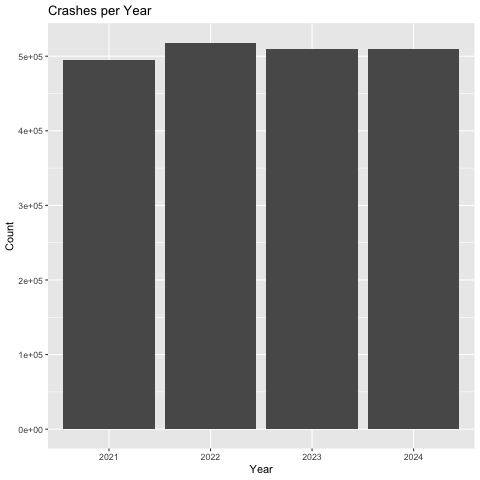

In [12]:
%%R                                                                                                            
  library(ggplot2)                                                                                               
  library(readr)                                                                                                 
  df_cleaned <- read_csv('Motor_Vehicle_Crashes_Cleaned.csv')                                                    
  ggplot(df_cleaned, aes(x=factor(Year))) +                                                                      
    geom_bar() +                                                                                                 
    labs(title='Crashes per Year', x='Year', y='Count')  

Rows: 2032927 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): Sex, Injury Severity, Injury Descriptor, License State Code
dbl (1): Year

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


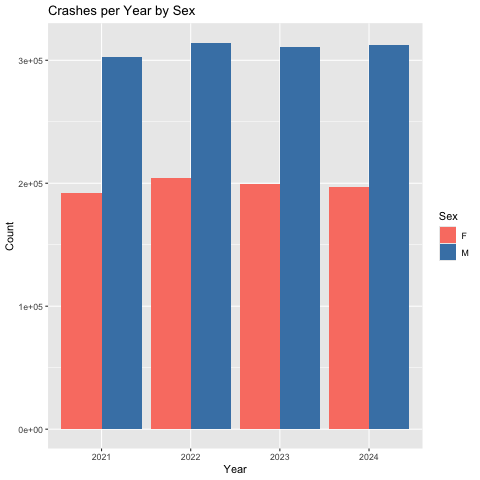

In [13]:
%%R                                                                                                            
  library(ggplot2)                                                                                             
  library(readr)                                                                                                 
  df_cleaned <- read_csv('Motor_Vehicle_Crashes_Cleaned.csv')                                                    
  df_sex <- df_cleaned[df_cleaned$Sex %in% c('M', 'F'), ]                                                        
  ggplot(df_sex, aes(x=factor(Year), fill=Sex)) +                                                                
    geom_bar(position='dodge') +                                                                                 
    scale_fill_manual(values=c('M'='steelblue', 'F'='salmon')) +                                                 
    labs(title='Crashes per Year by Sex', x='Year', y='Count')


Rows: 2032927 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): Sex, Injury Severity, Injury Descriptor, License State Code
dbl (1): Year

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor



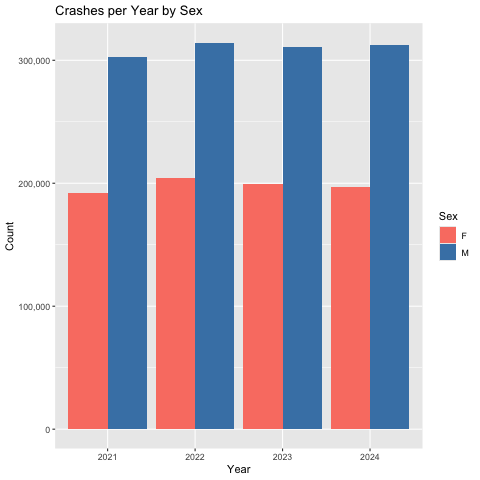

In [14]:
%%R                                                                                                            
  library(ggplot2)                                                                                               
  library(readr)                                                                                                 
  library(scales)                                                                                                
                  
  df_cleaned <- read_csv('Motor_Vehicle_Crashes_Cleaned.csv')
  df_sex <- df_cleaned[df_cleaned$Sex %in% c('M', 'F'), ]

  ggplot(df_sex, aes(x=factor(Year), fill=Sex)) +
    geom_bar(position='dodge') +
    scale_fill_manual(values=c('M'='steelblue', 'F'='salmon')) +
    scale_y_continuous(labels = comma) +
    labs(title='Crashes per Year by Sex', x='Year', y='Count')


Rows: 2032927 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): Sex, Injury Severity, Injury Descriptor, License State Code
dbl (1): Year

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


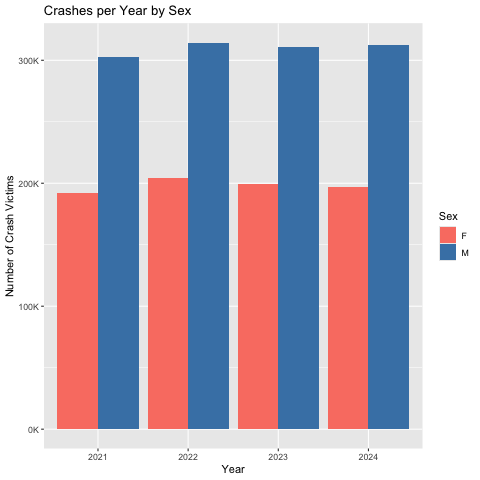

In [15]:
%%R                                                                                                            
  library(ggplot2)                                                                                               
  library(readr)                                                                                                 
  library(scales)                                                                                                
                                                                                                                 
  df_cleaned <- read_csv('Motor_Vehicle_Crashes_Cleaned.csv')
  df_sex <- df_cleaned[df_cleaned$Sex %in% c('M', 'F'), ]                                                        
                                                                                                                 
  ggplot(df_sex, aes(x=factor(Year), fill=Sex)) +
    geom_bar(position='dodge') +
    scale_fill_manual(values=c('M'='steelblue', 'F'='salmon')) +
    scale_y_continuous(labels = unit_format(unit = "people", scale = 1e-3, suffix = "K")) +
    labs(title='Crashes per Year by Sex', x='Year', y='Number of Crash Victims')

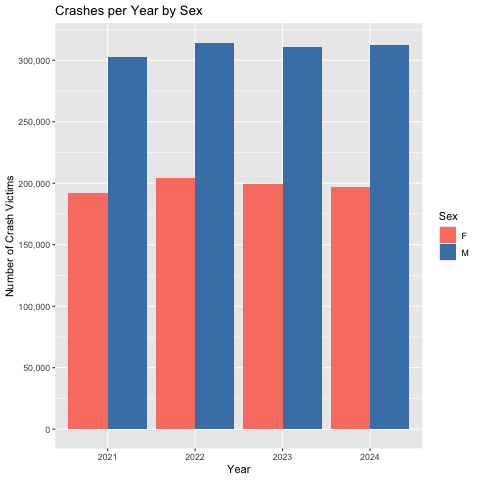

In [16]:
%%R                                                                                                            
  ggplot(df_sex, aes(x=factor(Year), fill=Sex)) +                                                                
    geom_bar(position='dodge') +                                                                                 
    scale_fill_manual(values=c('M'='steelblue', 'F'='salmon')) +                                                 
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(title='Crashes per Year by Sex', x='Year', y='Number of Crash Victims')                                 


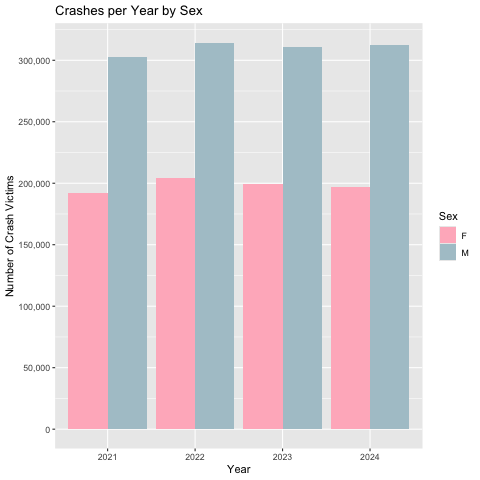

In [17]:
 %%R                                                                                                            
  ggplot(df_sex, aes(x=factor(Year), fill=Sex)) +                                                                
    geom_bar(position='dodge') +                                                                                 
    scale_fill_manual(values=c('M'='#AEC6CF', 'F'='#FFB7C5')) +                                                  
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(title='Crashes per Year by Sex', x='Year', y='Number of Crash Victims')

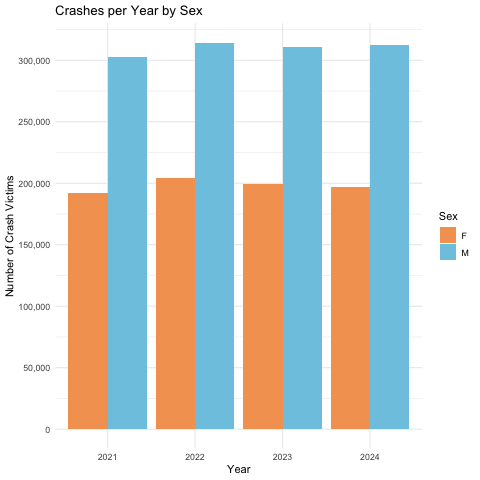

In [18]:
%%R                                                                                                            
  ggplot(df_sex, aes(x=factor(Year), fill=Sex)) +                                                              
    geom_bar(position='dodge') +                                                                                 
    scale_fill_manual(values=c('M'='#7EC8E3', 'F'='#F4A261')) +
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(title='Crashes per Year by Sex', x='Year', y='Number of Crash Victims') +                             
    theme_minimal()       

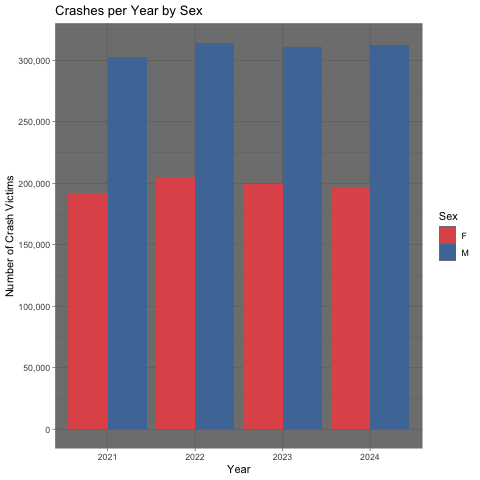

In [19]:
%%R                                                                                                            
  ggplot(df_sex, aes(x=factor(Year), fill=Sex)) +                                                                
    geom_bar(position='dodge') +                                                                                 
    scale_fill_manual(values=c('M'='#4E79A7', 'F'='#E15759')) +                                                  
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(title='Crashes per Year by Sex', x='Year', y='Number of Crash Victims') +
    theme_dark()                                                                                                 
                    

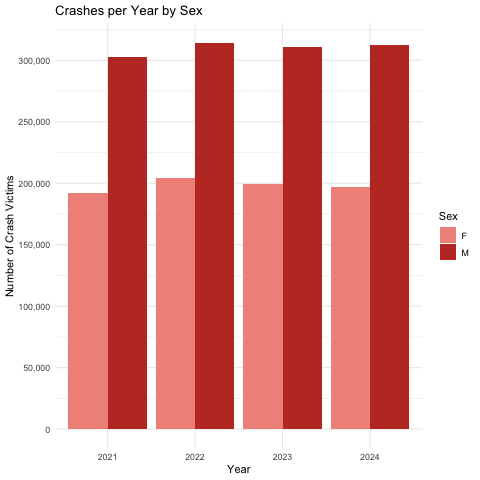

In [20]:
 %%R                                                                                                            
  ggplot(df_sex, aes(x=factor(Year), fill=Sex)) +                                                                
    geom_bar(position='dodge') +                                                                                 
    scale_fill_manual(values=c('M'='#C0392B', 'F'='#F1948A')) +                                                  
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(title='Crashes per Year by Sex', x='Year', y='Number of Crash Victims') +
    theme_minimal()     

`summarise()` has grouped output by 'Year'. You can override using the
`.groups` argument.


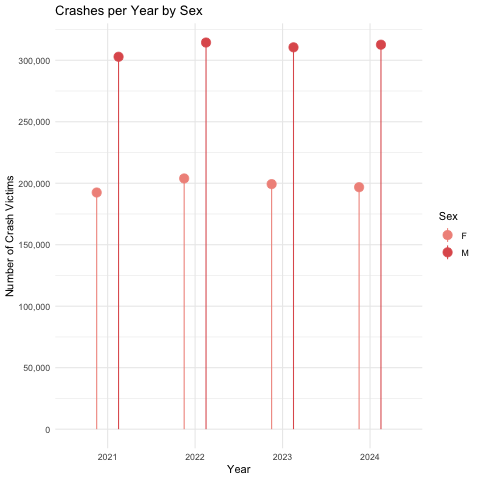

In [21]:
%%R                                                                                                            
  df_sex_count <- df_sex %>% group_by(Year, Sex) %>% summarise(Count = n())                                      
                                                                                                                 
  ggplot(df_sex_count, aes(x=factor(Year), y=Count, color=Sex, group=Sex)) +                                     
    geom_point(size=4, position=position_dodge(0.5)) +                                                           
    geom_linerange(aes(ymin=0, ymax=Count), position=position_dodge(0.5)) +
    scale_color_manual(values=c('M'='#E05C5C', 'F'='#F1948A')) +
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +
    labs(title='Crashes per Year by Sex', x='Year', y='Number of Crash Victims') +
    theme_minimal()



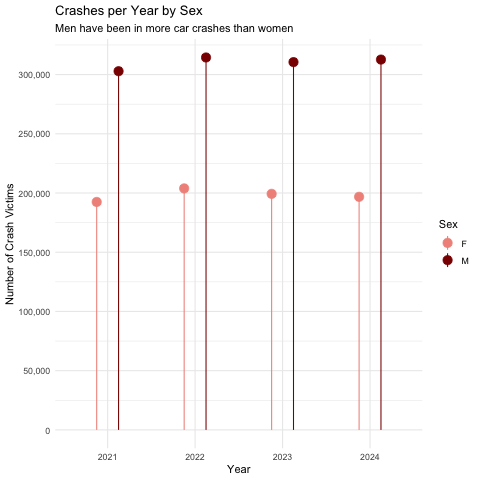

In [22]:
%%R                                                                                                            
  ggplot(df_sex_count, aes(x=factor(Year), y=Count, color=Sex, group=Sex)) +                                     
    geom_point(size=4, position=position_dodge(0.5)) +                                                           
    geom_linerange(aes(ymin=0, ymax=Count), position=position_dodge(0.5)) +                                      
    scale_color_manual(values=c('M'='#8B0000', 'F'='#F1948A')) +                                                 
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(                                                                                                        
      title='Crashes per Year by Sex',                                                                           
      subtitle='Men have been in more car crashes than women',
      x='Year',
      y='Number of Crash Victims'
    ) +
    theme_minimal() +
    theme(plot.title = element_text(hjust=0), plot.subtitle = element_text(hjust=0))


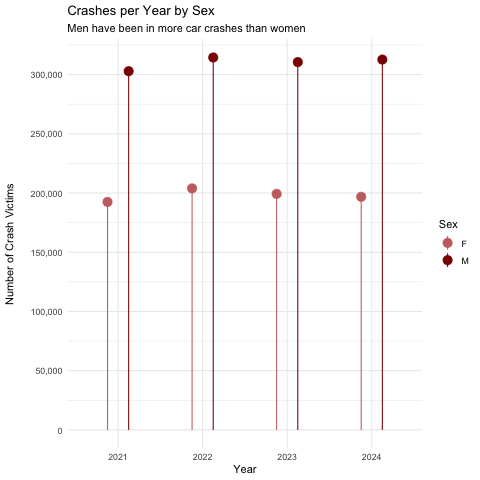

In [23]:
%%R                                                                                                            
  ggplot(df_sex_count, aes(x=factor(Year), y=Count, color=Sex, group=Sex)) +                                     
    geom_point(size=4, position=position_dodge(0.5)) +                                                           
    geom_linerange(aes(ymin=0, ymax=Count), position=position_dodge(0.5)) +
    scale_color_manual(values=c('M'='#8B0000', 'F'='#C97070')) +                                                 
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +
    labs(                                                                                                        
      title='Crashes per Year by Sex',                                                                           
      subtitle='Men have been in more car crashes than women',
      x='Year',
      y='Number of Crash Victims'
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust=0),
      plot.subtitle = element_text(hjust=0),
      axis.title.y = element_text(margin=margin(r=15))
    )

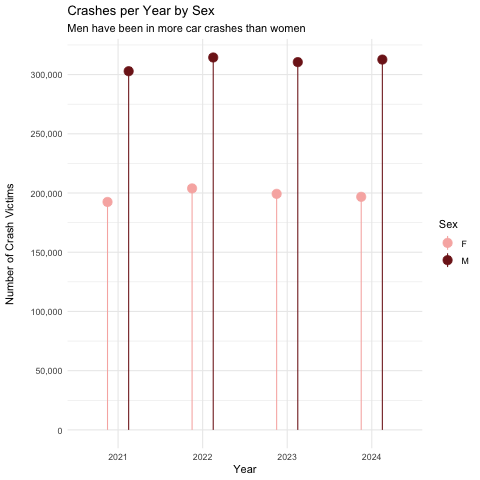

In [24]:
%%R                                                                                                            
  ggplot(df_sex_count, aes(x=factor(Year), y=Count, color=Sex, group=Sex)) +                                     
    geom_point(size=4, position=position_dodge(0.5)) +                                                           
    geom_linerange(aes(ymin=0, ymax=Count), position=position_dodge(0.5)) +                                      
    scale_color_manual(values=c('M'='#7F1D1D', 'F'='#F8B4B0')) +                                                 
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(                                                                                                        
      title='Crashes per Year by Sex',                                                                           
      subtitle='Men have been in more car crashes than women',
      x='Year',
      y='Number of Crash Victims'
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust=0),
      plot.subtitle = element_text(hjust=0),
      axis.title.y = element_text(margin=margin(r=15))
    )

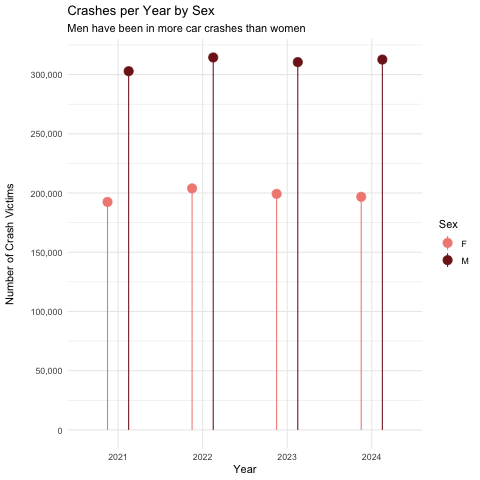

In [25]:
%%R                                                                                                            
  ggplot(df_sex_count, aes(x=factor(Year), y=Count, color=Sex, group=Sex)) +                                     
    geom_point(size=4, position=position_dodge(0.5)) +                                                           
    geom_linerange(aes(ymin=0, ymax=Count), position=position_dodge(0.5)) +                                      
    scale_color_manual(values=c('M'='#7F1D1D', 'F'='#F28B82')) +                                                 
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(                                                                                                        
      title='Crashes per Year by Sex',                                                                           
      subtitle='Men have been in more car crashes than women',
      x='Year',
      y='Number of Crash Victims'
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust=0),
      plot.subtitle = element_text(hjust=0),
      axis.title.y = element_text(margin=margin(r=15))
    )

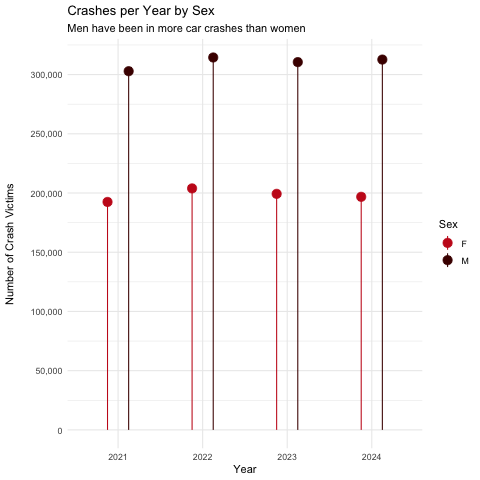

In [26]:
  %%R                                                                                                            
  ggplot(df_sex_count, aes(x=factor(Year), y=Count, color=Sex, group=Sex)) +                                     
    geom_point(size=4, position=position_dodge(0.5)) +                                                           
    geom_linerange(aes(ymin=0, ymax=Count), position=position_dodge(0.5)) +
    scale_color_manual(values=c('M'='#4A0000', 'F'='#C81E1E')) +                                                 
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(
      title='Crashes per Year by Sex',
      subtitle='Men have been in more car crashes than women',
      x='Year',
      y='Number of Crash Victims'
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust=0),
      plot.subtitle = element_text(hjust=0),
      axis.title.y = element_text(margin=margin(r=15))
    )

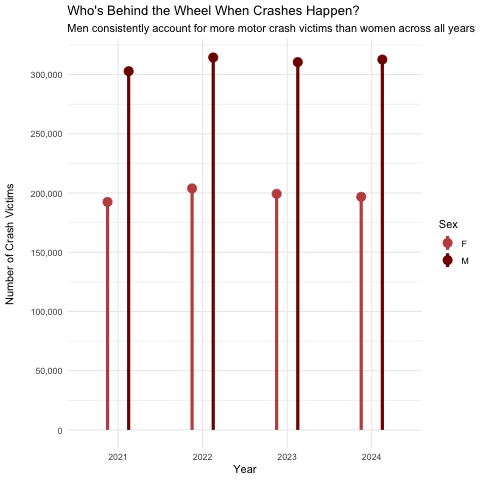

In [118]:
%%R                                                                                                            
  ggplot(df_sex_count, aes(x=factor(Year), y=Count, color=Sex, group=Sex)) +                                     
    geom_point(size=4, position=position_dodge(0.5)) +                                                           
    geom_linerange(aes(ymin=0, ymax=Count), position=position_dodge(0.5), linewidth=1.5) +                       
    scale_color_manual(values=c('M'='#800000', 'F'='#C05050')) +                                                 
    scale_y_continuous(breaks = seq(0, 350000, by = 50000), labels = comma) +                                    
    labs(                                                                                                        
      title="Who's Behind the Wheel When Crashes Happen?",                                                       
      subtitle='Men consistently account for more motor crash victims than women across all years',
      x='Year',
      y='Number of Crash Victims'
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust=0),
      plot.subtitle = element_text(hjust=0),
      axis.title.y = element_text(margin=margin(r=15))
    )

In [44]:
df_sev_year = df_sev_filtered[df_sev_filtered['Sex'].isin(['M', 'F'])].groupby(['Year', 'Injury Severity',     
'Sex']).size().reset_index(name='Count')                                                                       
df_sev_year  

,Year,Injury Severity,Sex,Count
0,2021,Killed,F,111
1,2021,Killed,M,482
2,2021,Minor,F,29311
3,2021,Minor,M,33453
4,2021,Moderate,F,3093
5,2021,Moderate,M,6022
6,2021,Severe,F,2216
7,2021,Severe,M,3993
8,2022,Killed,F,113
9,2022,Killed,M,445


In [74]:
df_sev_long = df_sev_year.pivot_table(index=['Injury Severity', 'Sex'], columns='Year',                        
values='Count').reset_index()
df_sev_long   

Year,Injury Severity,Sex,2021,2022,2023,2024
0,Killed,F,111.0,113.0,105.0,89.0
1,Killed,M,482.0,445.0,423.0,433.0
2,Minor,F,29311.0,29777.0,29736.0,28918.0
3,Minor,M,33453.0,33837.0,35497.0,36353.0
4,Moderate,F,3093.0,3458.0,3403.0,3359.0
5,Moderate,M,6022.0,6330.0,6387.0,6467.0
6,Severe,F,2216.0,2333.0,2630.0,2688.0
7,Severe,M,3993.0,4189.0,4518.0,4747.0


In [104]:
df_killed = df[df['Injury Severity'] == 'Killed'][['Year', 'Sex', 'Injury Severity']]                          
df_killed = df_killed[df_killed['Sex'].isin(['M', 'F'])]                                                     
df_killed_year = df_killed.groupby(['Year', 'Sex']).size().reset_index(name='Count')                           
df_killed_year  

,Year,Sex,Count
0,2021,F,111
1,2021,M,482
2,2022,F,113
3,2022,M,445
4,2023,F,105
5,2023,M,423
6,2024,F,89
7,2024,M,433


In [113]:
df_killed_wide = df_killed_year.pivot(index='Year', columns='Sex', values='Count').reset_index()               
df_killed_wide   

Sex,Year,F,M
0,2021,111,482
1,2022,113,445
2,2023,105,423
3,2024,89,433


In [115]:
df_killed_pct = df_killed_year.copy()                                                                          
df_killed_pct['Pct'] = df_killed_year.groupby('Year')['Count'].transform(lambda x: x / x.sum() * 100).round(1) 
df_killed_pct  


,Year,Sex,Count,Pct
0,2021,F,111,18.7
1,2021,M,482,81.3
2,2022,F,113,20.3
3,2022,M,445,79.7
4,2023,F,105,19.9
5,2023,M,423,80.1
6,2024,F,89,17.0
7,2024,M,433,83.0


In [117]:
df_killed_pct_wide = df_killed_pct.pivot(index='Year', columns='Sex', values='Pct').reset_index()              
df_killed_pct_wide                                                                                           
                         

Sex,Year,F,M
0,2021,18.7,81.3
1,2022,20.3,79.7
2,2023,19.9,80.1
3,2024,17.0,83.0


In [ ]:
import pandas as pd
df = pd.read_csv('/Users/amandafernandez/Desktop/Motor_Vehicle_Crashes/Motor_Vehicle_Crashes.csv')
df_sex_count = df[df['Sex'].isin(['M', 'F'])].groupby(['Year', 'Sex']).size().reset_index(name='Count')
print(df_sex_count)


In [119]:
import pandas as pd
df = pd.read_csv('/Users/amandafernandez/Desktop/Motor_Vehicle_Crashes/Motor_Vehicle_Crashes.csv')
df_sex_count = df[df['Sex'].isin(['M', 'F'])].groupby(['Year', 'Sex']).size().reset_index(name='Count')
print(df_sex_count)


   Year Sex   Count
0  2021   F  192461
1  2021   M  302850
2  2022   F  203898
3  2022   M  314431
4  2023   F  199298
5  2023   M  310526
6  2024   F  196792
7  2024   M  312671


In [120]:
df_killed = df[df['Injury Severity'] == 'Killed']
df_killed_sex = df_killed[df_killed['Sex'].isin(['M', 'F'])].groupby('Sex').size().reset_index(name='Count')
df_killed_sex['Pct'] = (df_killed_sex['Count'] / df_killed_sex['Count'].sum() * 100).round(1)
print(df_killed_sex)


  Sex  Count   Pct
0   F    418  19.0
1   M   1783  81.0
